# COLTIE Immersion · Week 1 · Tuesday — **LAB**
## Visualisation & EDA — now you build it

*Use this right after the lecture. The slides covered the ideas; here you make them real.*

**What you'll produce (≈30 min):** four figures + two seaborn charts on the cleaned crash data, then three written findings.

| Segment | Time | You make |
|---|---|---|
| Setup | 2 min | load the data |
| Figure 1 — Bar | 5 min | crashes by county |
| Figure 2 — Histogram | 5 min | vehicle speeds |
| Seaborn quickies | 5 min | distribution + correlation |
| Figure 3 — By hour | 5 min | crashes across the day |
| Figure 4 — Map | 5 min | crash locations |
| Findings | 3 min | three sentences |

**How the lab runs:** cells marked **▶ Build together** we do as a group — follow along and run them. Cells marked **✏️ Your turn** are yours to finish.

**Recall the chart chooser:** spread of one number → *histogram* · compare groups → *bar* · two numbers → *scatter* · over time → *line/bar* · location → *map*.

## 0 · Setup ▶️  *(run this one cell)*

Loads the cleaned Iowa crash data. Don't read it — just press play.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def _load_clean_crashes(n=1200, seed=42):
    g = np.random.default_rng(seed)
    counties=np.array(["Story","Polk","Linn","Scott","Johnson","Black Hawk"])
    routes  =np.array(["I-35","I-80","US-30","US-69","IA-210","IA-1"])
    weather =np.array(["Clear","Rain","Snow","Fog"]); lighting=np.array(["Daylight","Dark","Dusk","Dawn"])
    severity=np.array(["No Injury","Minor","Major","Fatal"])
    start=pd.Timestamp("2024-01-01"); day=g.integers(0,365,n)
    rush=g.random(n)<0.45; hour=np.where(rush,g.choice([7,8,16,17,18],n),g.integers(0,24,n))
    dt=start+pd.to_timedelta(day,"D")+pd.to_timedelta(hour,"h")+pd.to_timedelta(g.integers(0,60,n),"m")
    spd=g.choice([25,35,45,55,65,70],n); vs=np.clip(spd+g.normal(3,9,n),0,None).round(0)
    light=g.choice(lighting,n,p=[0.55,0.30,0.08,0.07])
    df=pd.DataFrame({"crash_id":[f"IA-2024-{i:05d}" for i in range(n)],"crash_datetime":dt,
        "county":g.choice(counties,n),"route":g.choice(routes,n),
        "severity":g.choice(severity,n,p=[0.62,0.28,0.085,0.015]),"num_vehicles":g.integers(1,5,n),
        "weather":g.choice(weather,n,p=[0.6,0.25,0.1,0.05]),"lighting":light,
        "speed_limit":spd,"vehicle_speed":vs,"wrong_way":g.random(n)<(0.02+0.05*(light=="Dark")),
        "latitude":g.uniform(40.5,43.3,n).round(5),"longitude":g.uniform(-96.5,-90.2,n).round(5)})
    df["vehicle_speed"]=df["vehicle_speed"].where(df["vehicle_speed"].between(0,150))
    for c in ["county","weather","lighting"]:
        df[c]=df[c].str.strip().str.title()
    df["hour"]=df["crash_datetime"].dt.hour
    return df

crashes = _load_clean_crashes()
sns.set_theme(style="whitegrid")
plt.rcParams.update({"axes.titlesize":13,"axes.titleweight":"bold","savefig.dpi":150,"savefig.bbox":"tight"})
NAVY, TEAL, AMBER, DARK_RED = "#0F2647", "#1C9C9C", "#F2A431", "#700500"
print(f"Loaded {len(crashes)} crashes. Let's build.")
crashes.head()

Loaded 1200 crashes. Let's build.


,crash_id,crash_datetime,county,route,severity,num_vehicles,weather,lighting,speed_limit,vehicle_speed,wrong_way,latitude,longitude,hour
0,IA-2024-00000,2024-02-02 14:37:00,Scott,IA-1,Major,2,Rain,Daylight,65,65.0,False,41.04515,-93.62082,14
1,IA-2024-00001,2024-10-09 14:49:00,Johnson,I-80,Minor,2,Fog,Daylight,35,45.0,False,42.25151,-93.02592,14
2,IA-2024-00002,2024-08-26 05:38:00,Scott,I-35,No Injury,3,Clear,Dark,35,16.0,False,42.65609,-92.26235,5
3,IA-2024-00003,2024-06-09 19:35:00,Story,I-80,Minor,4,Clear,Daylight,25,39.0,False,40.92969,-92.38691,19
4,IA-2024-00004,2024-06-07 16:28:00,Scott,IA-210,No Injury,2,Rain,Dark,25,41.0,False,41.39147,-91.78175,16


## 1 · Figure 1 — Bar chart
*Question: how do crashes compare across counties?*  →  **bar chart**
Recall the pattern from the lecture: **`fig, ax = plt.subplots()` → draw → label → title.**

**▶ Build together**

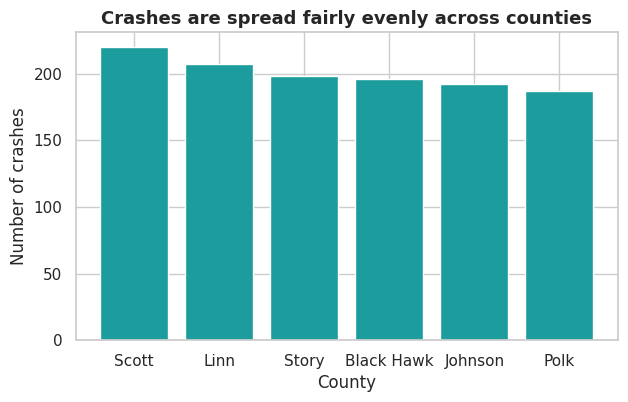

In [ ]:
counts = crashes["county"].value_counts()          # count crashes per county

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=TEAL)
ax.set_xlabel("County")
ax.set_ylabel("Number of crashes")
ax.set_title("Crashes are spread fairly evenly across counties")
fig.savefig("fig1_by_county.png")
plt.show()

**✏️ Your turn 1** — make the *same* bar chart for **`weather`** instead of `county`. The blanks are marked; then fix the title to match what you see.

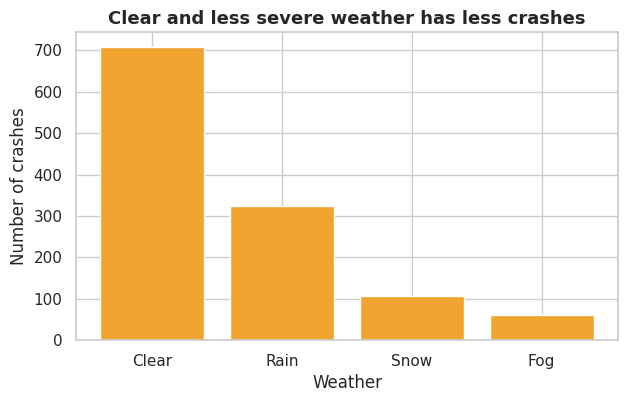

In [ ]:
# ✏️ Your turn 1
wcounts = crashes["weather"].value_counts()
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(wcounts.index, wcounts.values, color=AMBER)
ax.set_xlabel("Weather")
ax.set_ylabel("Number of crashes")
ax.set_title("Clear and less severe weather has less crashes")
plt.show()

## 2 · Figure 2 — Histogram
*Question: what's the spread of one number — how fast were vehicles going?*  →  **histogram**
Read it for the four things from the lecture: centre, spread, shape, outliers.

**▶ Build together**

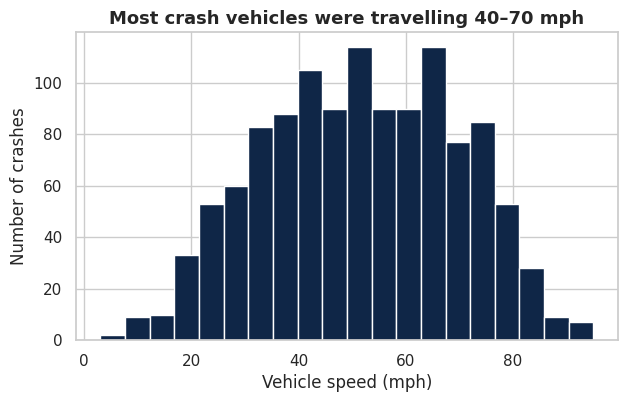

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(crashes["vehicle_speed"].dropna(), bins=20, color=NAVY, edgecolor="white")
ax.set_xlabel("Vehicle speed (mph)")
ax.set_ylabel("Number of crashes")
ax.set_title("Most crash vehicles were travelling 40–70 mph")
fig.savefig("fig2_speed.png")
plt.show()

**✏️ Your turn 2** — change one thing: try `bins=10`, then `bins=40`. What does too few / too many bins do? Then fix the title.

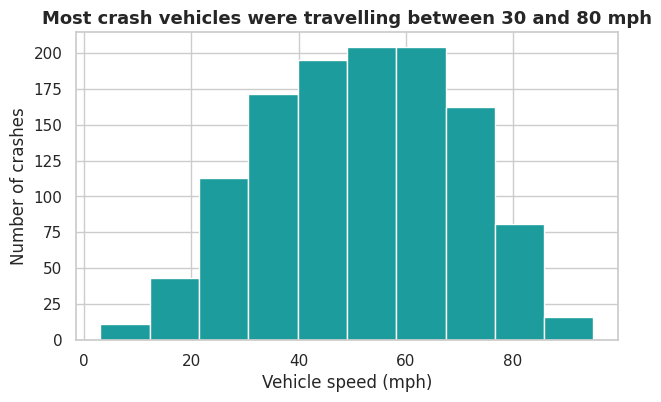

In [ ]:
# ✏️ Your turn 2  (try changing bins)
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(crashes["vehicle_speed"].dropna(), bins=10, color=TEAL, edgecolor="white")
ax.set_xlabel("Vehicle speed (mph)")
ax.set_ylabel("Number of crashes")
ax.set_title("Most crash vehicles were travelling between 30 and 80 mph")
plt.show()

## 3 · Seaborn quickies
*Recall: hand seaborn the whole DataFrame and name the columns — it does colours and the legend for you.*

**▶ Build together** — distribution split by a category

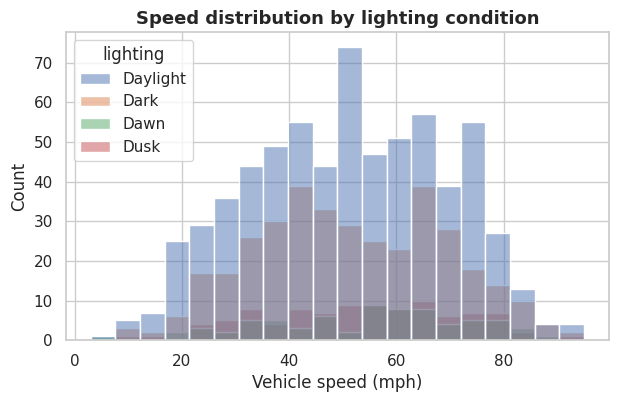

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=crashes, x="vehicle_speed", hue="lighting", bins=20, ax=ax)
ax.set_xlabel("Vehicle speed (mph)")
ax.set_title("Speed distribution by lighting condition")
plt.show()

**▶ Build together** — correlation heatmap *(near ±1 = strong, near 0 = no link; correlation ≠ causation)*

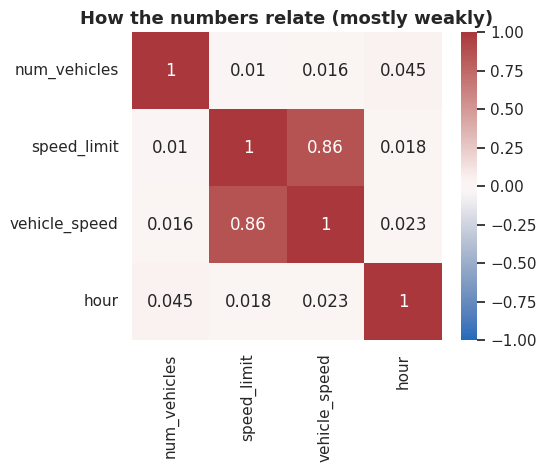

In [ ]:
numbers = crashes[["num_vehicles", "speed_limit", "vehicle_speed", "hour"]]
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(numbers.corr(), annot=True, cmap="vlag", center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title("How the numbers relate (mostly weakly)")
plt.show()

## 4 · Figure 3 — Crashes by hour
*Question: how do crashes change over the day?*  →  **time pattern (bar)**

**▶ Build together**

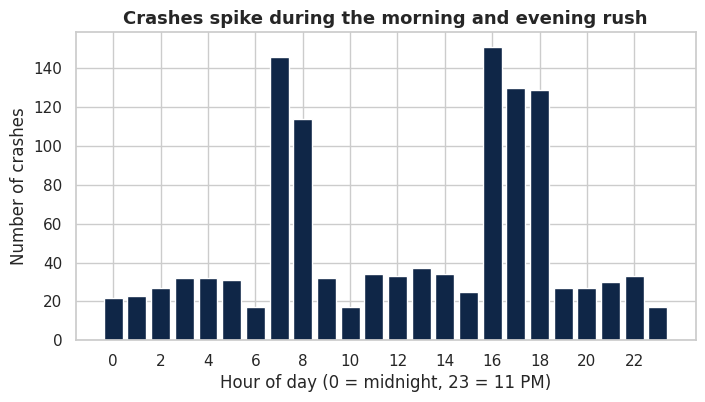

In [ ]:
hours = crashes.dropna(subset=["hour"]).copy()
hours["hour"] = hours["hour"].astype(int)             # 7.0 -> 7 for a tidy x-axis
by_hour = hours["hour"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_hour.index, by_hour.values, color=NAVY)
ax.set_xlabel("Hour of day (0 = midnight, 23 = 11 PM)")
ax.set_ylabel("Number of crashes")
ax.set_title("Crashes spike during the morning and evening rush")
ax.set_xticks(range(0, 24, 2))
fig.savefig("fig3_by_hour.png")
plt.show()

**✏️ Your turn 3** — make a bar chart of crashes by **day of the week**. `.dt.day_name()` pulls 'Monday', 'Tuesday', … out of each date. Then fix the title.

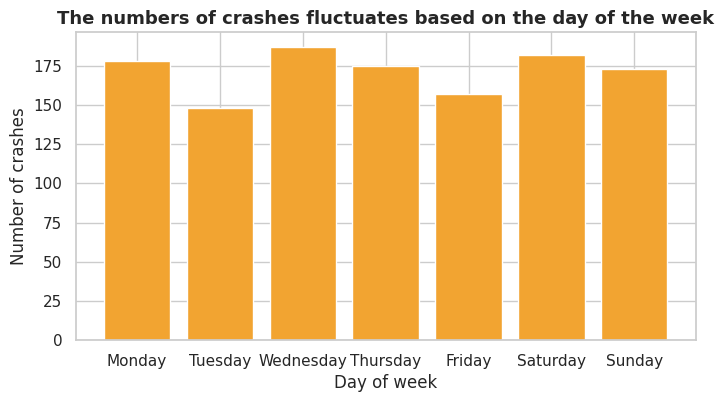

In [ ]:
# ✏️ Your turn 3
order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
by_day = crashes["crash_datetime"].dt.day_name().value_counts().reindex(order)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_day.index, by_day.values, color=AMBER)
ax.set_xlabel("Day of week")
ax.set_ylabel("Number of crashes")
ax.set_title("The numbers of crashes fluctuates based on the day of the week")
plt.show()

## 5 · Figure 4 — Map
*Question: where do crashes happen?*  →  **map / scatter**
We let seaborn colour the dots by severity automatically.

**▶ Build together**

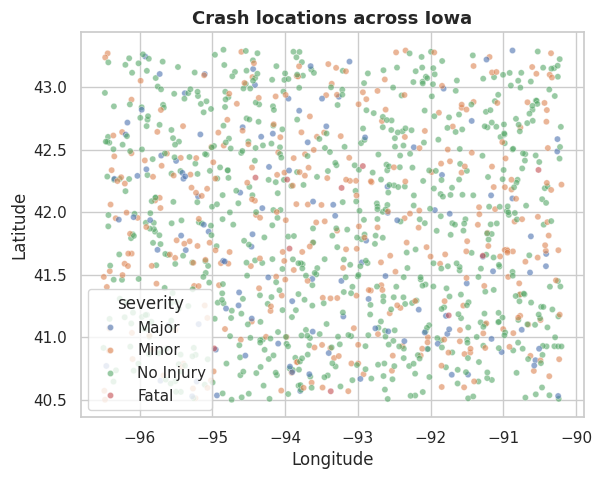

In [ ]:
geo = crashes.dropna(subset=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(6.5, 5))
sns.scatterplot(data=geo, x="longitude", y="latitude", hue="severity",
                s=20, alpha=0.6, ax=ax)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Crash locations across Iowa")
fig.savefig("fig4_map.png")
plt.show()

**▶ Build together (bonus)** — a real interactive map. Just run it.

In [ ]:
try:
    import folium
    m = folium.Map(location=[42.0, -93.5], zoom_start=7, tiles="cartodbpositron")
    for _, row in geo.sample(150, random_state=1).iterrows():
        folium.CircleMarker([row["latitude"], row["longitude"]], radius=3, color=TEAL, fill=True).add_to(m)
    display(m)
except Exception:
    print("(folium not installed — the scatter above is your Figure 4.)")

## 6 · Check your deliverable ✔️

In [ ]:
from pathlib import Path
figures = {
    "fig1_by_county.png": "Crashes by county",
    "fig2_speed.png":     "Vehicle speed distribution",
    "fig3_by_hour.png":   "Crashes by hour of day",
    "fig4_map.png":       "Crash locations across Iowa",
}
for fn, what in figures.items():
    print(("✓" if Path(fn).exists() else "✗ missing"), f" {fn:<20} — {what}")

✓  fig1_by_county.png   — Crashes by county
✓  fig2_speed.png       — Vehicle speed distribution
✓  fig3_by_hour.png     — Crashes by hour of day
✓  fig4_map.png         — Crash locations across Iowa


## 7 · Write three findings ✍️

Look back over everything you just made. In **three sentences**, write:

1. **One pattern** you saw — be specific (*"crashes peak at 7–8 AM and 4–6 PM"*, not *"there are patterns"*).
2. **One thing that surprised you**, if anything.
3. **One question** these charts make you want to answer next.

> This is the output of stage 4 (Explore) from the pipeline. It's also the seed of your Week 2 research problem — keep it.
> And remember: this is *practice* data, so don't over-read it.

In [ ]:
# Write your three findings here (as comments or a printed string):
findings = """
1. Pattern: A pattern I saw was that most crashes in the data happened in the range of 40 to 70 mph.
2. Surprise: I was surprised when I noticed that the day of the week has an impact on the number of crashes.
3. Question: How does the location of the crash impact the likelihood of that crash happening?
"""
print(findings)


1. Pattern: A pattern I saw was that most crashes in the data happened in the range of 40 to 70 mph.
2. Surprise: I was surprised when I noticed that the day of the week has an impact on the number of crashes.
3. Question: How does the location of the crash impact the likelihood of that crash happening?



---
## Homework — due before Wednesday (~30 min)

1. **Make one new chart** we didn't build together (e.g. crashes by `route`, or `vehicle_speed` vs `speed_limit` as a scatter). Same pattern: `fig, ax` → draw → label → title.
2. **Write 2–3 sentences** about your most interesting chart: what it shows, and one question it raises.
3. **Bring it** Wednesday — clear title and labelled axes is all I'm checking for.

---
## Completed Homework:

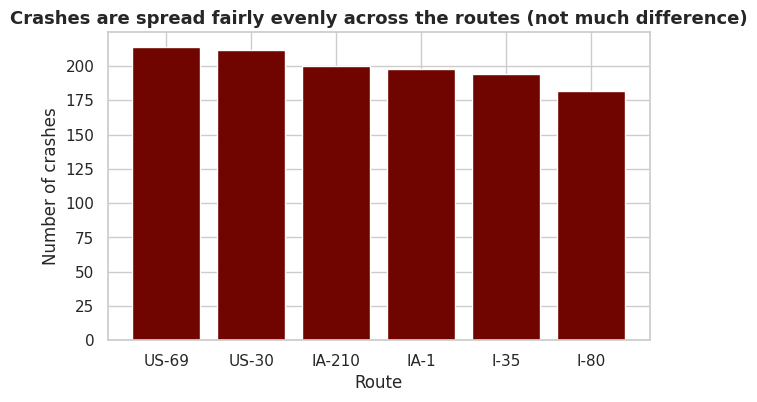

In [ ]:
counts = crashes["route"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(counts.index, counts.values, color=DARK_RED)
ax.set_xlabel("Route")
ax.set_ylabel("Number of crashes")
ax.set_title("Crashes are spread fairly evenly across the routes (not much difference)")
fig.savefig("fig1_by_route.png")
plt.show()

In [ ]:
# Write your three findings here (as comments or a printed string):
explanation = """
The crashes shown on the graph are spread pretty evenly throughout the different routes in the crash data. \nHowever, I was fascinated in realizing that the US routes had more crashes compared to the Iowa state routes. \nAn interesting question this brought up is what aspects about the routes affect the number of crashes they have?
"""
print(explanation)


The crashes shown on the graph are spread pretty evenly throughout the different routes in the crash data. 
However, I was fascinated in realizing that the US routes had more crashes compared to the Iowa state routes. 
An interesting question this brought up is what aspects about the routes affect the number of crashes they have?

